c:\Users\ferdi\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,No,Kode Wilayah,Wilayah,Jumlah
0,1,11.0,Aceh,16795
1,2,12.0,Sumatera Utara,39553
2,3,13.0,Sumatera Barat,16088
3,4,14.0,Riau,26881
4,5,15.0,Jambi,11351


[[0.02325614]
 [0.05838345]
 [0.02216487]
 [0.03882403]
 [0.01485324]]


,Wilayah,Jumlah,Status_Prioritas
38,NaN,649600,Prioritas Tinggi (Zona Merah)
11,Jawa Barat,114513,Prioritas Tinggi (Zona Merah)
12,Jawa Tengah,59662,Prioritas Sedang (Zona Kuning)
14,Jawa Timur,57026,Prioritas Sedang (Zona Kuning)
1,Sumatera Utara,39553,Prioritas Rendah (Zona Hijau)



--- [SS BAGIAN 4] GRAFIK VISUALISASI ---


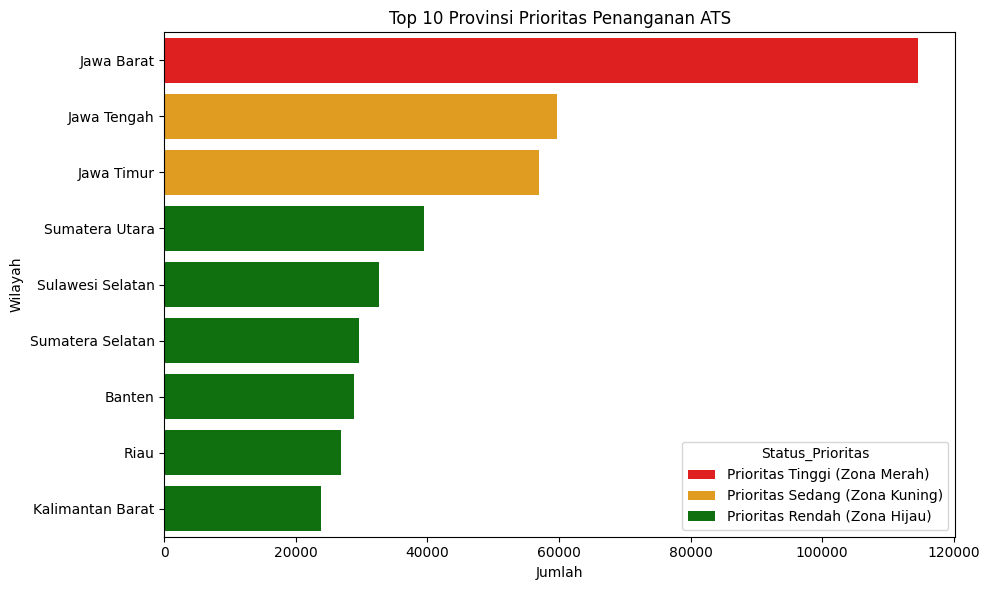

* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


c:\Users\ferdi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import gradio as gr

# ==========================================
# TAHAP 1 & 2: DATA LOADING & UNDERSTANDING
# ==========================================
file_path = 'jumlah-anak-tidak-sekolah-pada-sd-sederajat-dikarenakan-putus-sekolah-atau-lulus-tidak-melanjutkan-2024-sd-mi-sederajat.xlsx'
df = pd.read_excel(file_path)
df = df.dropna(subset=['Jumlah'])
display(df.head())

# ==========================================
# TAHAP 3: DATA PREPARATION
# ==========================================
X = df[['Jumlah']]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

# ==========================================
# TAHAP 4: MODELING (K-MEANS 5 CLUSTER)
# ==========================================
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_scaled)
df['Cluster_Label'] = kmeans.labels_

# ==========================================
# TAHAP 5: EVALUASI & INTERPRETASI (MAPPING)
# ==========================================
centroid_stat = df.groupby('Cluster_Label')['Jumlah'].mean().sort_values(ascending=False)
indexes = centroid_stat.index

mapping_priority = {
    indexes[0]: 'Prioritas Tinggi (Zona Merah)',
    indexes[1]: 'Prioritas Tinggi (Zona Merah)',
    indexes[2]: 'Prioritas Sedang (Zona Kuning)',
    indexes[3]: 'Prioritas Rendah (Zona Hijau)',
    indexes[4]: 'Prioritas Rendah (Zona Hijau)'
}

df['Status_Prioritas'] = df['Cluster_Label'].map(mapping_priority)
display(df[['Wilayah', 'Jumlah', 'Status_Prioritas']].sort_values(by='Jumlah', ascending=False).head(5))

# Visualisasi Bar Plot
plt.figure(figsize=(10, 6))
custom_colors = {'Prioritas Tinggi (Zona Merah)': 'red', 'Prioritas Sedang (Zona Kuning)': 'orange', 'Prioritas Rendah (Zona Hijau)': 'green'}
sns.barplot(x='Jumlah', y='Wilayah', hue='Status_Prioritas', data=df.sort_values('Jumlah', ascending=False).head(10), palette=custom_colors, dodge=False)
plt.title("Top 10 Provinsi Prioritas Penanganan ATS")
plt.tight_layout()
plt.savefig("grafik_hasil.png")
print("\n--- [SS BAGIAN 4] GRAFIK VISUALISASI ---")
plt.show()

# ==========================================
# TAHAP 6: DEPLOYMENT (GRADIO APP)
# ==========================================
def prediksi_prioritas(jumlah_siswa):
    input_data = np.array([[jumlah_siswa]])
    input_scaled = scaler.transform(input_data)
    pred_cluster = kmeans.predict(input_scaled)[0]
    status = mapping_priority[pred_cluster]
    if "Merah" in status:
        rekomendasi = "DARURAT: Perlu intervensi pusat segera. Alokasikan anggaran khusus dan tim task force."
    elif "Kuning" in status:
        rekomendasi = "PERHATIAN: Perlu monitoring intensif dan program beasiswa tambahan."
    else:
        rekomendasi = "AMAN: Pertahankan program yang ada, lakukan maintenance rutin."

    return status, rekomendasi

with gr.Blocks() as interface:
    
    gr.HTML(
        """
            <h1 style="text-align:center;margin-bottom:5px;">Sistem Deteksi Prioritas Penanganan Anak Putus Sekolah</h1>
        """
    )
    gr.Markdown("Masukkan jumlah anak tidak sekolah untuk mengetahui apakah wilayah tersebut masuk Zona Merah, Kuning, atau Hijau.")
    
    jumlah_input = gr.Number(label="Masukkan Jumlah Anak Tidak Sekolah")
    
    submit_btn = gr.Button("Submit")
    
    status_output = gr.Markdown(label="Status Prioritas Wilayah")
    rekom_output = gr.Markdown(label="Rekomendasi Kebijakan")
    
    submit_btn.click(
        fn=prediksi_prioritas,
        inputs=jumlah_input,
        outputs=[status_output, rekom_output]
    )

interface.launch(share=True)